In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

reg = "../artifacts/eval/eval_results_checkpoint_epochbest_20260910-110534.pt"
upper = "../artifacts/eval/eval_results_checkpoint_epochbest_20260910-110537.pt"
baseline = "../artifacts/eval/eval_results_checkpoint_epochbest_20260910-135126.pt"
def get_json(path):
    with open(path, "r") as f:
        return json.load(f)

In [2]:
data_reg = get_json(reg)
data_upper = get_json(upper)
data_baseline = get_json(baseline)

In [3]:
def object_to_dataframe(data, rnn=False):
    to_return = {}
    to_return["x"] = data["x"]
    to_return["mean"] = data["mean"]
    to_return["logvar"] = data["logvar"]
    to_return["losses"] = data["losses"]    
    to_return["losses_position"] = data["losses_position"]
    to_return["mse_losses"] = data["mse_losses"]
    to_return["mse_losses_position"] = data["mse_losses_position"]

    to_return["mse_loss"] = data["mse_loss"]
    #to_return["losses"] = data["losses"]

    for k in list(to_return.keys()):
        try:
            print("Key: ", k , " Len: ", len(to_return[k]))
        except:
            print("did not work for" , k)
    return pd.DataFrame.from_dict(to_return)

In [4]:
df_reg = object_to_dataframe(data_reg)
df_upper = object_to_dataframe(data_upper)

df_baseline = object_to_dataframe(data_baseline, rnn=True)

Key:  x  Len:  5433
Key:  mean  Len:  5433
Key:  logvar  Len:  5433
Key:  losses  Len:  5433
Key:  losses_position  Len:  5433
Key:  mse_losses  Len:  5433
Key:  mse_losses_position  Len:  5433
did not work for mse_loss
Key:  x  Len:  5433
Key:  mean  Len:  5433
Key:  logvar  Len:  5433
Key:  losses  Len:  5433
Key:  losses_position  Len:  5433
Key:  mse_losses  Len:  5433
Key:  mse_losses_position  Len:  5433
did not work for mse_loss
Key:  x  Len:  5433
Key:  mean  Len:  5433
Key:  logvar  Len:  5433
Key:  losses  Len:  5433
Key:  losses_position  Len:  5433
Key:  mse_losses  Len:  5433
Key:  mse_losses_position  Len:  5433
did not work for mse_loss


MSE ERRORS PER POSITION: 
NLL ERRORS PER POSITION: 
MSE ERRORS PER POSITION: 
NLL ERRORS PER POSITION: 


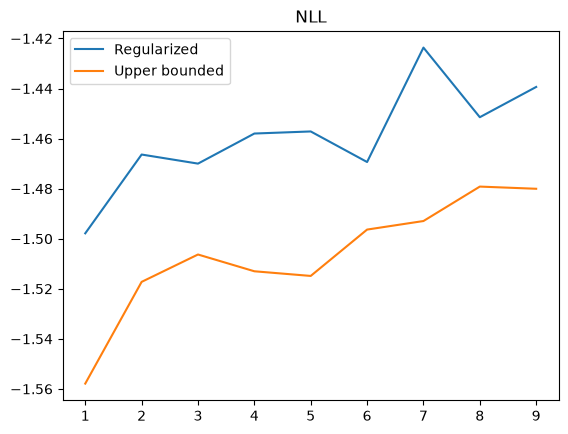

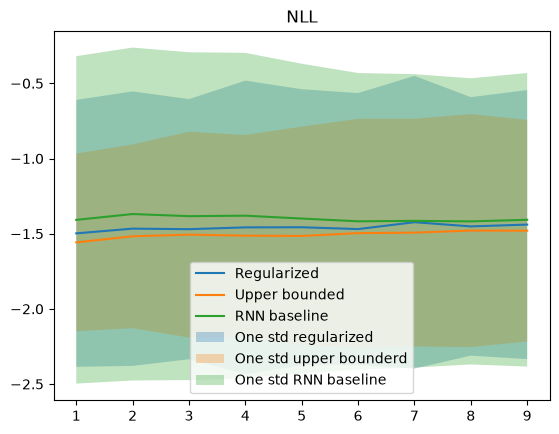

In [5]:


def get_horizon_error_std(new, old, rnn, title):
    errors_array_new = np.stack(new)
    errors_array_old = np.stack(old)
    errors_array_rnn = np.stack(rnn)

    mean_new = np.mean(errors_array_new, axis=0)
    mean_old = np.mean(errors_array_old, axis=0)
    mean_rnn = np.mean(errors_array_rnn, axis=0)

   
    std_old = np.std(errors_array_old, axis=0)
    lower_old = mean_old -  std_old
    upper_old = mean_old +  std_old

    std_new = np.std(errors_array_new, axis=0)
    lower_new = mean_new -  std_new
    upper_new = mean_new +  std_new

    std_rnn = np.std(errors_array_rnn, axis=0)
    lower_rnn = mean_rnn - std_rnn
    upper_rnn= mean_rnn + std_rnn
    
    x = np.arange(1, len(mean_new))

    fig, ax = plt.subplots()
    ax.set_xticks(x)


    ax.plot(x,mean_new[:len(x)], label="Regularized")
    ax.plot(x,mean_old[:len(x)], label="Upper bounded")
    ax.plot(x,mean_rnn[:len(x)], label="RNN baseline")
    ax.fill_between(x,lower_new[:len(x)], upper_new[:len(x)], alpha=0.3, label="One std regularized")

    ax.fill_between(x,lower_old[:len(x)], upper_old[:len(x)], alpha=0.3, label="One std upper bounderd")
    ax.fill_between(x,lower_rnn[:len(x)], upper_rnn[:len(x)], alpha=0.3, label="One std RNN baseline")


    ax.set_title(title)
    ax.legend()

    
def get_horizon_error(new, old, title):
    errors_array_new = np.stack(new)
    errors_array_old = np.stack(old)

    mean_new = np.mean(errors_array_new, axis=0)
    mean_old = np.mean(errors_array_old, axis=0)


    x = np.arange(1, len(mean_new))

    fig, ax = plt.subplots()
    ax.set_xticks(x)


    ax.plot(x,mean_new[:len(x)], label="Regularized")
    ax.plot(x,mean_old[:len(x)], label="Upper bounded")

    ax.set_title(title)
    ax.legend()


print("MSE ERRORS PER POSITION: ")
#get_horizon_error(df_new["mse_losses_position"], df_old["mse_losses_position"], title="MSE")
print("NLL ERRORS PER POSITION: ")
get_horizon_error(df_reg["losses_position"],df_upper["losses_position"], title="NLL")
get_horizon_error_std(df_reg["losses_position"],df_upper["losses_position"], df_baseline["losses_position"], title="NLL")



print("MSE ERRORS PER POSITION: ")
#get_horizon_error_std(df_new["mse_losses_position"], df_old["mse_losses_position"], df_rnn["mse_losses_position"], title="MSE")
print("NLL ERRORS PER POSITION: ")
#get_horizon_error_std(df_new["losses_position"],df_old["losses_position"], df_rnn["losses_position"], title="NLL")

MSE


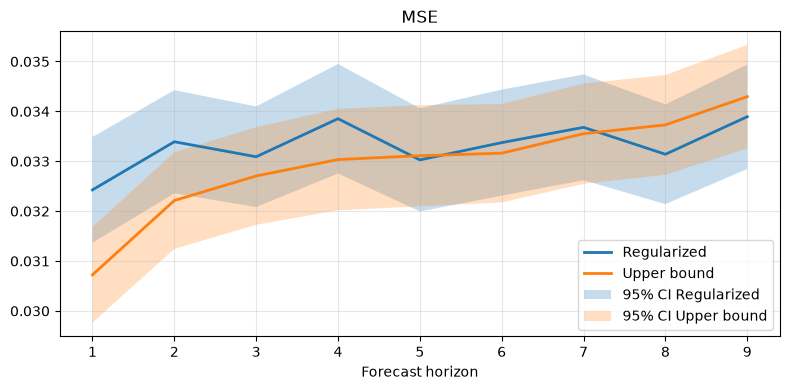

NLL


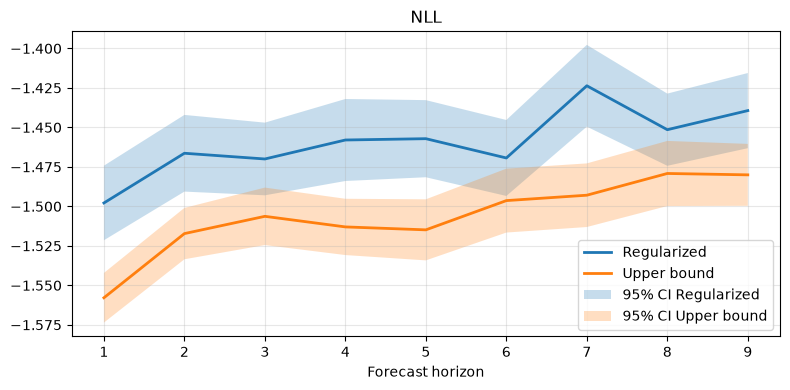

MSE


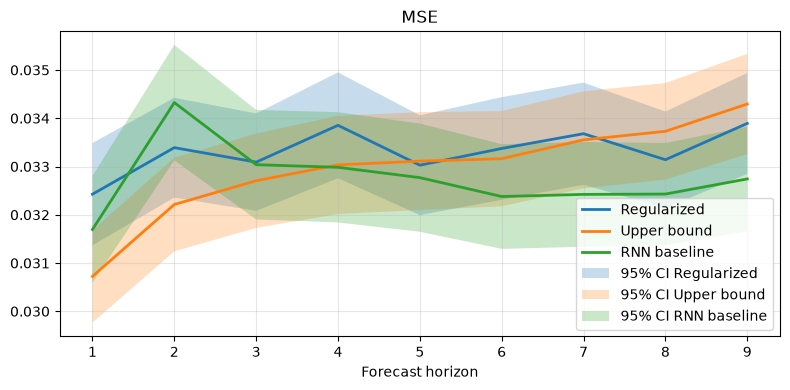

NLL


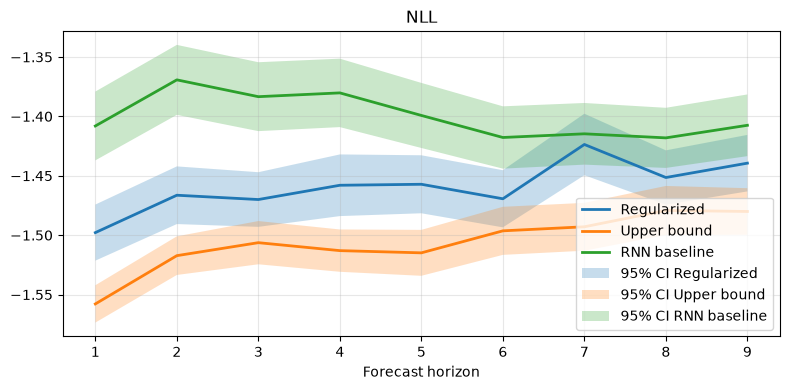

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_horizon_metric(new, old, rnn=None, title="title"):
    errors_new = np.stack(new)
    errors_old = np.stack(old)
    if rnn is not None:
        errors_rnn = np.stack(rnn)
    
    mean_new = np.mean(errors_new, axis=0)
    mean_old = np.mean(errors_old, axis=0)
    if rnn is not None:
        mean_rnn = np.mean(errors_rnn, axis=0)

    std_new = np.std(errors_new, axis=0, ddof=1)
    std_old = np.std(errors_old, axis=0, ddof=1)
    if rnn is not None:
        std_rnn = np.std(errors_rnn, axis=0, ddof=1)

    n_new = errors_new.shape[0]
    n_old = errors_old.shape[0]
    if rnn is not None:
        n_rnn = errors_rnn.shape[0]

    # 95% confidence intervals
    ci_new = 1.96 * std_new / np.sqrt(n_new)
    ci_old = 1.96 * std_old / np.sqrt(n_old)
    if rnn is not None:
        ci_rnn = 1.96 * std_rnn / np.sqrt(n_rnn)

    x = np.arange(1, len(mean_new))

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(x, mean_new[:len(x)], lw=2, label="Regularized")
    ax.plot(x, mean_old[:len(x)], lw=2, label="Upper bound")
    if rnn is not None:
        ax.plot(x, mean_rnn[:len(x)], lw=2, label="RNN baseline")

    ax.fill_between(
        x,
        mean_new[:len(x)] - ci_new[:len(x)],
        mean_new[:len(x)] + ci_new[:len(x)],
        alpha=0.25,
        label="95% CI Regularized"
    )

    ax.fill_between(
        x,
        mean_old[:len(x)] - ci_old[:len(x)],
        mean_old[:len(x)] + ci_old[:len(x)],
        alpha=0.25,
        label="95% CI Upper bound"
    )

    if rnn is not None:
        ax.fill_between(
            x,
            mean_rnn[:len(x)] - ci_rnn[:len(x)],
            mean_rnn[:len(x)] + ci_rnn[:len(x)],
            alpha=0.25,
            label="95% CI RNN baseline"
        )

    ax.set_xlabel("Forecast horizon")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


print("MSE")
plot_horizon_metric(
    df_reg["mse_losses_position"],
    df_upper["mse_losses_position"],
    title="MSE"
)
print("NLL")
plot_horizon_metric(
    df_reg["losses_position"],
    df_upper["losses_position"],
    title="NLL"
)


print("MSE")
plot_horizon_metric(
    df_reg["mse_losses_position"],
    df_upper["mse_losses_position"],
   df_baseline["mse_losses_position"],
    title="MSE"
)

print("NLL")
plot_horizon_metric(
    df_reg["losses_position"],
    df_upper["losses_position"],
    df_baseline["losses_position"],
    title="NLL"
)

In [7]:
def plot_difference(new, old, title):
    errors_new = np.stack(new)
    errors_old = np.stack(old)

    diff = errors_new - errors_old

    mean_diff = np.mean(diff, axis=0)
    std_diff = np.std(diff, axis=0, ddof=1)

    ci = 1.96 * std_diff / np.sqrt(diff.shape[0])

    x = np.arange(1, len(mean_diff) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.axhline(0, color="black", linestyle="--", alpha=0.7)

    ax.plot(x, mean_diff, lw=2, color="tab:green")

    ax.fill_between(
        x,
        mean_diff - ci,
        mean_diff + ci,
        alpha=0.25,
        color="tab:green"
    )

    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("New − Old")
    ax.set_title(title)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print("MSE")
plot_difference(
    df_new["mse_losses_position"],
    df_old["mse_losses_position"],
    "MSE"
)

print("NLL")
plot_difference(
    df_new["losses_position"],
    df_old["losses_position"],
    "NLL"
)

MSE


NameError: name 'df_new' is not defined